## Import pakietów, funkcji i klas


In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

path_crus = "data/VLagun_Crus_Basins.csv"
path_rotif = "data/VLagun_Rotif_Basins.csv"

df_crus = pd.read_csv(path_crus)
df_rotif = pd.read_csv(path_rotif)

display(df_crus.head())
display(df_rotif.head())

print("CRUS shape:", df_crus.shape)
print("ROTIF shape:", df_rotif.shape)

print("\nTypy danych (CRUS):")
print(df_crus.dtypes)
print("\nTypy danych (ROTIF):")
print(df_rotif.dtypes)


,Bosmina longirostris,Ceriodaphnia sp.,Diaphanosoma brachyurum,Leptodora kindtii,Acartia longiremis,Acartia tonsa,Eurytemora affinis,Cyclops sp.,Nauplii Cyclopoida,Nauplii Calanoida,Thermocyclops oithonoides,Eurytemora lacustris,Basin
0,0.0,0.0,0.0,0.0,2.0710,0.9298,0.9251,0.0000,0.0025,0.0257,0.0000,0.0,0
1,0.0,0.0,0.0,0.0,0.5014,0.0378,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0
2,0.0,0.0,0.0,0.0,0.0931,0.0000,0.0000,0.0093,0.0138,0.0006,0.0091,0.0,0
3,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0129,0.0060,0.0140,0.0155,0.0179,0.0,0
4,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0141,0.0000,0.0093,0.0007,0.0166,0.0,0


,Anureopsis fissa,Ascomorpha saltans,Asplanchna priodonta,Brachionus angularis,Brachionus calyciflorus calyciflorus,Brachionus calyciflorus f.amphiceros,Brachionus calyciflorus spinosus,Brachionus urceolaris,Brachionus calyciflorus f.anureiformis,Filinia longiseta,Keratella cochlearis cochlearis,Keratella cochlearis f.tecta,Keratella quadrata,Polyarthra vulgaris,Polyarthra platyptera,Pompholyx sp.,Synchaeta sp.,Trichocerca pusilla,Trichocerca similis,Basin
0,0.0000,0.0068,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.0,1.3152,0.8920,0.2714,0.0000,0.0313,0.0,0.0000,0.0000,0.0045,0.0009,0
1,0.0003,0.0000,0.0556,0.0000,0.0179,0.0,0.0,0.0,0.0,0.0769,0.0640,0.0464,0.0000,0.0111,0.0,0.0000,0.0437,0.0041,0.0020,0
2,0.0001,0.0000,0.0014,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0466,0.0120,0.0044,0.0000,0.0000,0.0,0.0001,0.0000,0.0000,0.0000,0
3,0.0001,0.0000,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0313,0.0079,0.0040,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0
4,0.0001,0.0000,0.0000,0.0003,0.0000,0.0,0.0,0.0,0.0,0.0491,0.0143,0.0019,0.0026,0.0000,0.0,0.0001,0.0000,0.0000,0.0000,0


CRUS shape: (155, 13)
ROTIF shape: (155, 20)

Typy danych (CRUS):
Bosmina longirostris         float64
Ceriodaphnia sp.             float64
Diaphanosoma brachyurum      float64
Leptodora kindtii            float64
Acartia longiremis           float64
Acartia tonsa                float64
Eurytemora affinis           float64
Cyclops sp.                  float64
Nauplii Cyclopoida           float64
Nauplii Calanoida            float64
Thermocyclops oithonoides    float64
Eurytemora lacustris         float64
Basin                          int64
dtype: object

Typy danych (ROTIF):
Anureopsis fissa                          float64
Ascomorpha saltans                        float64
Asplanchna priodonta                      float64
Brachionus angularis                      float64
Brachionus calyciflorus calyciflorus      float64
Brachionus calyciflorus f.amphiceros      float64
Brachionus calyciflorus spinosus          float64
Brachionus urceolaris                     float64
Brachionus calyci

## Uzyskanie danych i wstępne przekształcenia (EDA, rozkład klas, korelacje z Basin)

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

path_crus = "data/VLagun_Crus_Basins.csv"
path_rotif = "data/VLagun_Rotif_Basins.csv"
# Rozkład klas
print("Rozkład Basin – CRUS:")
print(df_crus["Basin"].value_counts(normalize=True))
print("\nRozkład Basin – ROTIF:")
print(df_rotif["Basin"].value_counts(normalize=True))

# Statystyki opisowe
display(df_crus.describe())
display(df_rotif.describe())

# Korelacje z Basin
corr_crus = df_crus.corr(numeric_only=True)["Basin"].sort_values(ascending=False)
corr_rotif = df_rotif.corr(numeric_only=True)["Basin"].sort_values(ascending=False)

print("\nKorelacje z Basin – CRUS:")
display(corr_crus)
print("\nKorelacje z Basin – ROTIF:")
display(corr_rotif)


Rozkład Basin – CRUS:
Basin
0    0.580645
1    0.419355
Name: proportion, dtype: float64

Rozkład Basin – ROTIF:
Basin
0    0.580645
1    0.419355
Name: proportion, dtype: float64


,Bosmina longirostris,Ceriodaphnia sp.,Diaphanosoma brachyurum,Leptodora kindtii,Acartia longiremis,Acartia tonsa,Eurytemora affinis,Cyclops sp.,Nauplii Cyclopoida,Nauplii Calanoida,Thermocyclops oithonoides,Eurytemora lacustris,Basin
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000
mean,0.001770,0.122872,1.041621,0.000069,0.681388,0.257751,1.730630,0.696490,0.060157,0.044977,0.017011,0.032689,0.419355
std,0.014631,0.833839,3.760413,0.000462,1.942163,0.788665,5.378542,2.727436,0.183739,0.102760,0.065486,0.107470,0.495053
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004750,0.000700,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000300,0.022900,0.003700,0.014000,0.004000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.084050,0.000000,0.310950,0.071300,0.323150,0.033000,0.040050,0.032200,0.000000,0.000000,1.000000
max,0.165300,7.791200,24.439300,0.004200,17.094500,5.822700,39.001600,19.217900,1.952000,0.748600,0.459200,0.605800,1.000000


,Anureopsis fissa,Ascomorpha saltans,Asplanchna priodonta,Brachionus angularis,Brachionus calyciflorus calyciflorus,Brachionus calyciflorus f.amphiceros,Brachionus calyciflorus spinosus,Brachionus urceolaris,Brachionus calyciflorus f.anureiformis,Filinia longiseta,Keratella cochlearis cochlearis,Keratella cochlearis f.tecta,Keratella quadrata,Polyarthra vulgaris,Polyarthra platyptera,Pompholyx sp.,Synchaeta sp.,Trichocerca pusilla,Trichocerca similis,Basin
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000
mean,0.000010,0.000757,0.010614,0.016005,0.027501,0.007255,0.000434,0.000103,0.005092,0.097882,0.288126,0.032786,0.016579,0.012690,0.018806,0.000797,0.001870,0.000659,0.000628,0.419355
std,0.000047,0.003113,0.047679,0.062015,0.114569,0.038003,0.002167,0.000943,0.032482,0.267643,0.771833,0.114241,0.071685,0.049164,0.092257,0.003224,0.011232,0.002004,0.002393,0.495053
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001000,0.001750,0.001000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020500,0.014600,0.003300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.004550,0.000000,0.000000,0.000000,0.000000,0.000000,0.051200,0.048850,0.009850,0.001500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,0.000400,0.019700,0.476300,0.551600,0.853700,0.369200,0.017900,0.010300,0.362400,1.541000,5.311100,1.264800,0.803800,0.474500,0.887400,0.025200,0.117700,0.013200,0.018600,1.000000



Korelacje z Basin – CRUS:


Basin                        1.000000
Cyclops sp.                  0.297203
Nauplii Cyclopoida           0.221122
Bosmina longirostris         0.142032
Diaphanosoma brachyurum      0.123413
Ceriodaphnia sp.             0.092250
Eurytemora affinis           0.084313
Acartia longiremis           0.058407
Nauplii Calanoida            0.041652
Leptodora kindtii            0.020246
Eurytemora lacustris        -0.009055
Acartia tonsa               -0.059344
Thermocyclops oithonoides   -0.146741
Name: Basin, dtype: float64


Korelacje z Basin – ROTIF:


Basin                                     1.000000
Trichocerca pusilla                       0.227026
Pompholyx sp.                             0.183335
Asplanchna priodonta                      0.136528
Filinia longiseta                         0.135988
Polyarthra vulgaris                       0.131298
Keratella quadrata                        0.120342
Brachionus calyciflorus calyciflorus      0.113780
Keratella cochlearis cochlearis           0.112134
Brachionus angularis                      0.111214
Trichocerca similis                       0.105751
Polyarthra platyptera                     0.055068
Keratella cochlearis f.tecta              0.027244
Brachionus calyciflorus f.amphiceros      0.014770
Brachionus calyciflorus spinosus          0.000722
Brachionus calyciflorus f.anureiformis   -0.008745
Brachionus urceolaris                    -0.014045
Ascomorpha saltans                       -0.053900
Synchaeta sp.                            -0.058005
Anureopsis fissa               

##  Zbudowanie i ocena modelu regresji logistycznej dla skorupiaków (CRUS)

Accuracy (CRUS): 0.7659574468085106

Macierz pomyłek (CRUS):
[[26  1]
 [10 10]]

Raport klasyfikacji (CRUS):
              precision    recall  f1-score   support

           0       0.72      0.96      0.83        27
           1       0.91      0.50      0.65        20

    accuracy                           0.77        47
   macro avg       0.82      0.73      0.74        47
weighted avg       0.80      0.77      0.75        47



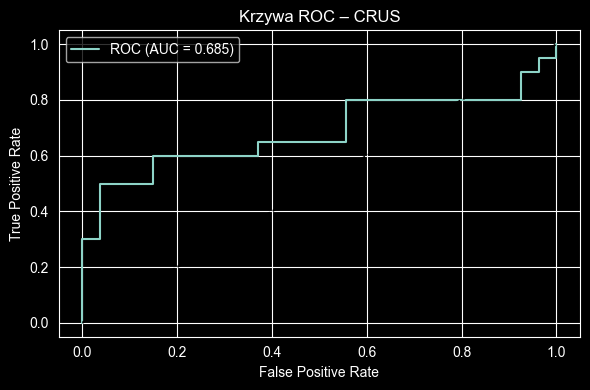

In [3]:
# Dane dla CRUS
X_crus = df_crus.drop(columns=["Basin"])
y_crus = df_crus["Basin"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_crus, y_crus, test_size=0.25, random_state=42, stratify=y_crus
)

pipe_crus = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

pipe_crus.fit(Xc_train, yc_train)

yc_pred = pipe_crus.predict(Xc_test)
yc_prob = pipe_crus.predict_proba(Xc_test)[:, 1]

print("Accuracy (CRUS):", metrics.accuracy_score(yc_test, yc_pred))
print("\nMacierz pomyłek (CRUS):")
print(metrics.confusion_matrix(yc_test, yc_pred))
print("\nRaport klasyfikacji (CRUS):")
print(metrics.classification_report(yc_test, yc_pred))

fpr_c, tpr_c, _ = metrics.roc_curve(yc_test, yc_prob)
auc_c = metrics.roc_auc_score(yc_test, yc_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr_c, tpr_c, label=f"ROC (AUC = {auc_c:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Krzywa ROC – CRUS")
plt.legend()
plt.tight_layout()
plt.show()


## Zbudowanie i ocena modelu regresji logistycznej dla wrotków (ROTIF)

Accuracy (ROTIF): 0.6170212765957447

Macierz pomyłek (ROTIF):
[[21  6]
 [12  8]]

Raport klasyfikacji (ROTIF):
              precision    recall  f1-score   support

           0       0.64      0.78      0.70        27
           1       0.57      0.40      0.47        20

    accuracy                           0.62        47
   macro avg       0.60      0.59      0.59        47
weighted avg       0.61      0.62      0.60        47



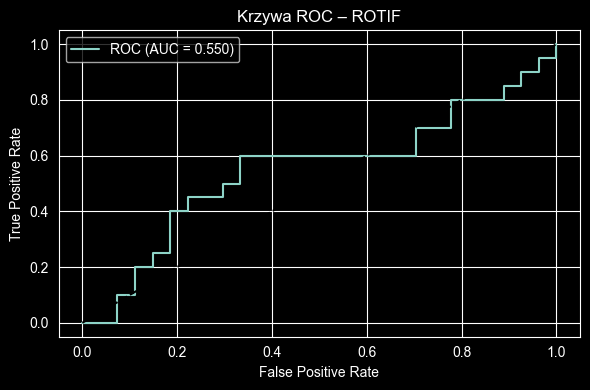

In [7]:
# Dane dla ROTIF
X_rot = df_rotif.drop(columns=["Basin"])
y_rot = df_rotif["Basin"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_rot, y_rot, test_size=0.25, random_state=42, stratify=y_rot
)

pipe_rot = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

pipe_rot.fit(Xr_train, yr_train)

yr_pred = pipe_rot.predict(Xr_test)
yr_prob = pipe_rot.predict_proba(Xr_test)[:, 1]

print("Accuracy (ROTIF):", metrics.accuracy_score(yr_test, yr_pred))
print("\nMacierz pomyłek (ROTIF):")
print(metrics.confusion_matrix(yr_test, yr_pred))
print("\nRaport klasyfikacji (ROTIF):")
print(metrics.classification_report(yr_test, yr_pred))

fpr_r, tpr_r, _ = metrics.roc_curve(yr_test, yr_prob)
auc_r = metrics.roc_auc_score(yr_test, yr_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr_r, tpr_r, label=f"ROC (AUC = {auc_r:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Krzywa ROC – ROTIF")
plt.legend()
plt.tight_layout()
plt.show()
